![image.png](https://i.imgur.com/a3uAqnb.png)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')


## **Load data**

In [2]:
import kagglehub
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-dataset


In [3]:
train_df = pd.read_csv(f'{path}/train.csv', encoding='latin1')

test_path = f'{path}/test.csv'
test_df   = pd.read_csv(test_path, encoding='latin1')


In [4]:
train_df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [5]:
test_df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [6]:
# Keep only rows where both text and sentiment are present
train_df = train_df[['text','sentiment']].dropna().reset_index(drop=True)
test_df = test_df[['text','sentiment']].dropna().reset_index(drop=True)

print("Train:", train_df.shape, "| Test:", test_df.shape)
train_df.head()

Train: (27480, 2) | Test: (3534, 2)


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [7]:
test_df.head()

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


# **1️⃣ Exploratory Data Analysis (EDA)**

Goal: Understand the dataset before touching the text.

🔍 What to check:
- Dataset shape
- Column names & types
- Class distribution (balanced or not)
- Missing values
- Duplicate rows
- Review length distribution


In [8]:
# Basic info
print("Shape:", train_df.shape)
print("\nColumns & dtypes:")
print(train_df.dtypes)
print("\nMissing values:")
print(train_df.isnull().sum())
print("\nDuplicate rows:", train_df.duplicated().sum())


Shape: (27480, 2)

Columns & dtypes:
text         object
sentiment    object
dtype: object

Missing values:
text         0
sentiment    0
dtype: int64

Duplicate rows: 0


In [9]:
# Class distribution
print("Class distribution:")
print(train_df['sentiment'].value_counts())

Class distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


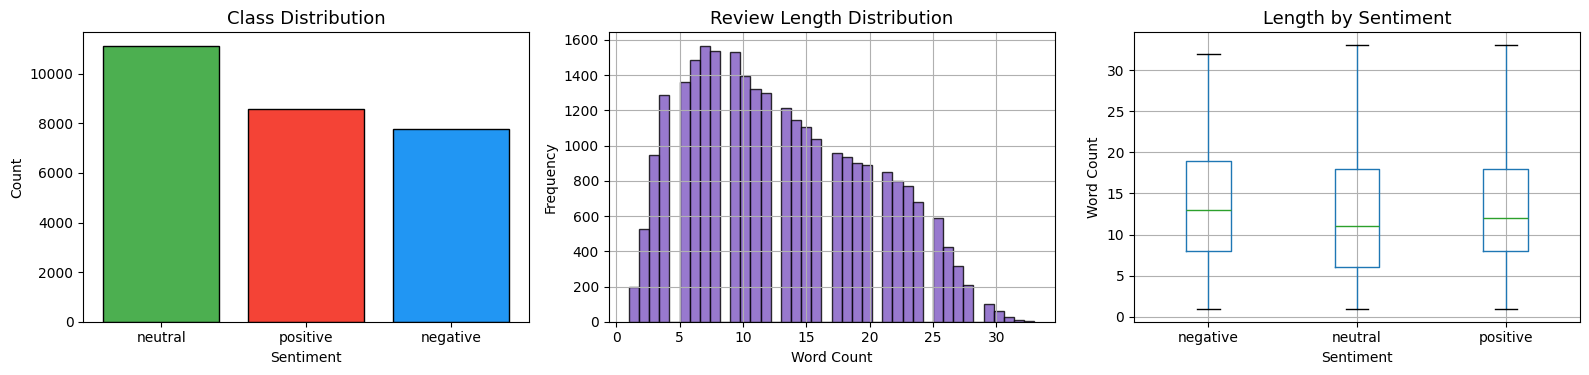

In [10]:
# Add review length feature
train_df['review_length'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class counts
counts = train_df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#4CAF50','#F44336','#2196F3'][:len(counts)], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')

# Review length histogram
train_df['review_length'].hist(bins=40, ax=axes[1], color='#7E57C2', edgecolor='black', alpha=0.8)
axes[1].set_title('Review Length Distribution', fontsize=13)
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency')

# Length by sentiment
train_df.boxplot(column='review_length', by='sentiment', ax=axes[2])
axes[2].set_title('Length by Sentiment', fontsize=13)
axes[2].set_xlabel('Sentiment'); axes[2].set_ylabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.show()


In [11]:
# Summary stats of review length
train_df.groupby('sentiment')['review_length'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,7781.0,13.47,6.87,1.0,8.0,13.0,19.0,32.0
neutral,11117.0,12.34,7.06,1.0,6.0,11.0,18.0,33.0
positive,8582.0,13.11,6.75,1.0,8.0,12.0,18.0,33.0


## **2️⃣ Text Cleaning & Preprocessing**

Goal: Convert raw text into clean, usable format.

🧹 Common Steps:
- Lowercasing
- Remove punctuation
- Remove numbers
- Remove stopwords
- Tokenization
- Stemming or Lemmatization


In [12]:
import re
import string
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)

from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer


In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)                       # remove URLs
    text = re.sub(r'\d+', '', text)                                   # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)


In [14]:
# Before vs after
pd.set_option('display.max_colwidth', 120)
train_df[['text', 'clean_text']].head(5)

,text,clean_text
0,"I`d have responded, if I were going",id responded going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,bos bullying
3,what interview! leave me alone,interview leave alone
4,"Sons of ****, why couldn`t they put them on the releases we already bought",son couldnt put release already bought


## **3️⃣ Feature Engineering (Preparing Data for Modeling)**

Goal: Convert text into numerical format.

Common Methods:
- Bag of Words (CountVectorizer)
- TF-IDF
- Label Encoding


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.model_selection import train_test_split

In [16]:
# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])
y_test  = le.transform(test_df['sentiment'])

print("Classes:", le.classes_)
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))


Classes: ['negative' 'neutral' 'positive']
Encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [17]:
# TF-IDF vectorisation (used by ML models)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

print(f"TF-IDF feature matrix: train={X_train_tfidf.shape}, test={X_test_tfidf.shape}")


TF-IDF feature matrix: train=(27480, 10000), test=(3534, 10000)


In [18]:
# Vocabulary for the RNN — build a simple integer tokeniser
from collections import Counter

def build_vocab(texts, max_vocab=10000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {w: i+2 for i, (w, _) in enumerate(counter.most_common(max_vocab))}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def encode_texts(texts, vocab, max_len=50):
    encoded = []
    for t in texts:
        ids = [vocab.get(w, 1) for w in t.split()][:max_len]
        ids += [0] * (max_len - len(ids))   # pad
        encoded.append(ids)
    return encoded

MAX_LEN  = 50
vocab    = build_vocab(train_df['clean_text'].tolist())
VOCAB_SIZE = len(vocab)

X_train_seq = encode_texts(train_df['clean_text'].tolist(), vocab, MAX_LEN)
X_test_seq  = encode_texts(test_df['clean_text'].tolist(),  vocab, MAX_LEN)
print(f"Vocab size: {VOCAB_SIZE} | Sequence length: {MAX_LEN}")


Vocab size: 10002 | Sequence length: 50


## **4️⃣ Machine Learning Models (sklearn)**

Goal: Train multiple models and compare performance.

🤖 Models:
- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVM)
- Random Forest


In [19]:
from sklearn.linear_model  import LogisticRegression
from sklearn.naive_bayes   import MultinomialNB
from sklearn.svm           import LinearSVC
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import classification_report, confusion_matrix, accuracy_score
import time


In [20]:
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'SVM (Linear)':        LinearSVC(C=1.0, max_iter=3000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

ml_results = {}
for name, model in ml_models.items():
    t0 = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    preds = model.predict(X_test_tfidf)
    infer_time = time.time() - t1

    acc = accuracy_score(y_test, preds)
    ml_results[name] = {
        'model': model, 'preds': preds,
        'accuracy': acc,
        'train_time': train_time,
        'infer_time': infer_time,
    }
    print(f"{'='*45}")
    print(f"{name}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Train time  : {train_time:.2f}s  |  Inference time: {infer_time:.4f}s")
    print(classification_report(y_test, preds, target_names=le.classes_))


Logistic Regression
  Accuracy    : 0.7043
  Train time  : 2.12s  |  Inference time: 0.0010s
              precision    recall  f1-score   support

    negative       0.73      0.64      0.68      1001
     neutral       0.64      0.75      0.69      1430
    positive       0.79      0.71      0.75      1103

    accuracy                           0.70      3534
   macro avg       0.72      0.70      0.71      3534
weighted avg       0.71      0.70      0.71      3534

Naive Bayes
  Accuracy    : 0.6290
  Train time  : 0.01s  |  Inference time: 0.0009s
              precision    recall  f1-score   support

    negative       0.67      0.57      0.62      1001
     neutral       0.56      0.70      0.62      1430
    positive       0.73      0.58      0.65      1103

    accuracy                           0.63      3534
   macro avg       0.65      0.62      0.63      3534
weighted avg       0.64      0.63      0.63      3534

SVM (Linear)
  Accuracy    : 0.6703
  Train time  : 0.54s  |

## **5️⃣ Model Evaluation**

Goal: Measure performance properly.

📊 Metrics: Accuracy · Precision · Recall · F1-score · Confusion Matrix


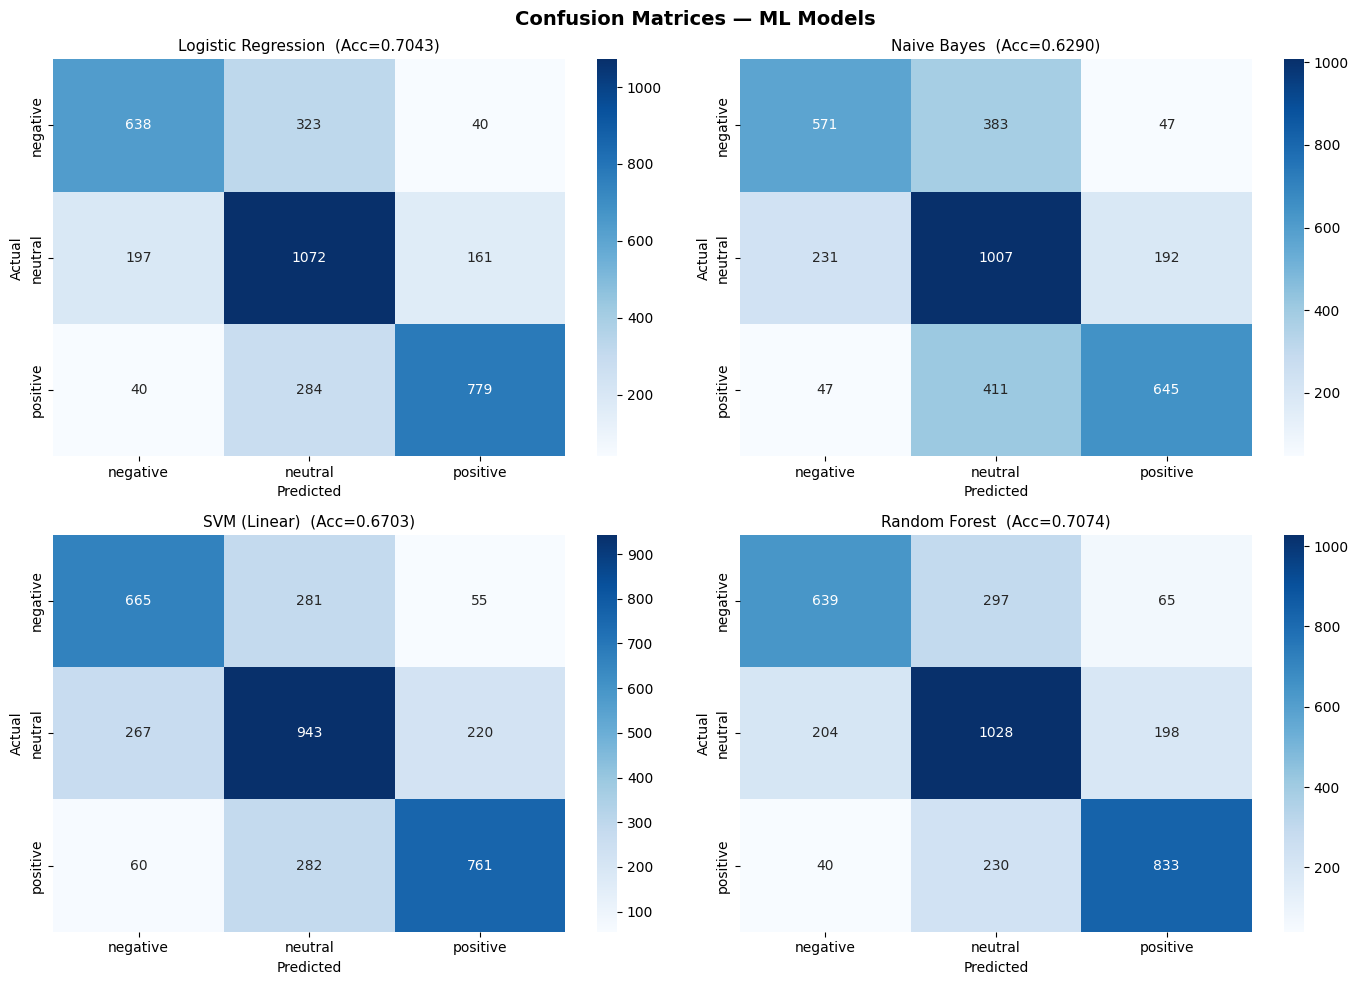

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(ml_results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    axes[i].set_title(f"{name}  (Acc={res['accuracy']:.4f})", fontsize=11)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — ML Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


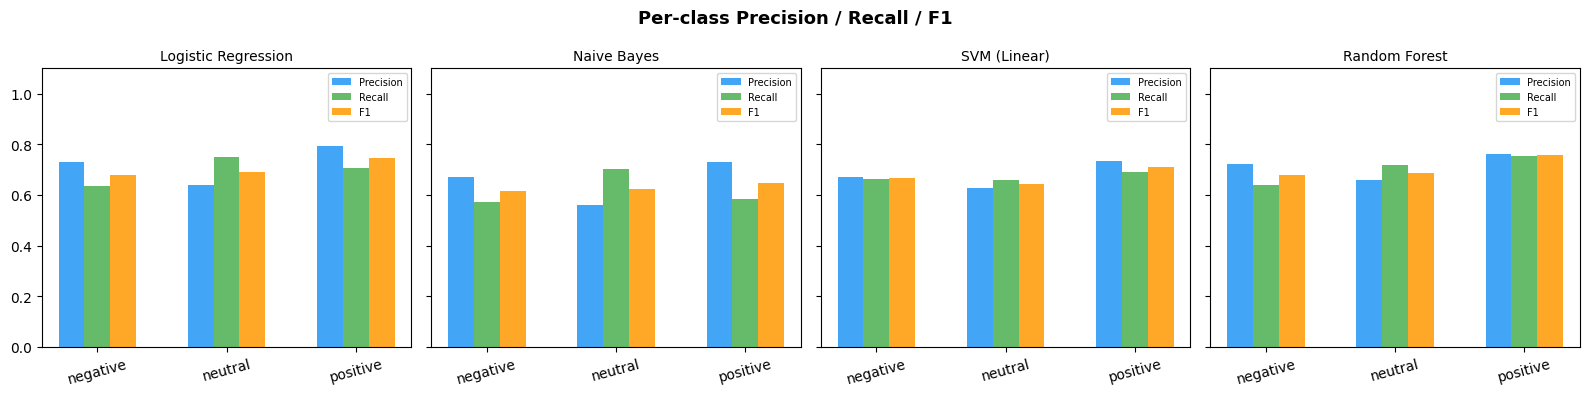

In [22]:
# Per-class F1 bar chart
fig, axes = plt.subplots(1, len(ml_results), figsize=(16, 4), sharey=True)
for ax, (name, res) in zip(axes, ml_results.items()):
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f, _ = precision_recall_fscore_support(y_test, res['preds'],
                                                  labels=range(len(le.classes_)))
    x = np.arange(len(le.classes_))
    ax.bar(x - 0.2, p, 0.2, label='Precision', color='#42A5F5')
    ax.bar(x,       r, 0.2, label='Recall',    color='#66BB6A')
    ax.bar(x + 0.2, f, 0.2, label='F1',        color='#FFA726')
    ax.set_xticks(x); ax.set_xticklabels(le.classes_, rotation=15)
    ax.set_title(name, fontsize=10); ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7)

plt.suptitle('Per-class Precision / Recall / F1', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## **6️⃣ Neural Network (Deep Learning)**

Goal: Build an **ANN** and an **RNN (LSTM)** using PyTorch.

Steps:
1. Convert data to PyTorch Tensors
2. Create Dataset & DataLoader
3. Define models (ANN on TF-IDF | RNN/LSTM on sequences)
4. Train and evaluate
5. Plot Loss & Accuracy curves


In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.sparse import issparse
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
NUM_CLASSES = len(le.classes_)


Device: cuda


In [24]:
# ── Dataset helpers ──────────────────────────────────────────────────────────
class TfidfDataset(Dataset):
    def __init__(self, X, y):
        if issparse(X): X = X.toarray()
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 64

# ANN loaders (TF-IDF input)
ann_train_loader = DataLoader(TfidfDataset(X_train_tfidf, y_train), batch_size=BATCH, shuffle=True)
ann_test_loader  = DataLoader(TfidfDataset(X_test_tfidf,  y_test),  batch_size=BATCH)

# RNN loaders (integer sequences)
rnn_train_loader = DataLoader(SeqDataset(X_train_seq, y_train), batch_size=BATCH, shuffle=True)
rnn_test_loader  = DataLoader(SeqDataset(X_test_seq,  y_test),  batch_size=BATCH)


In [25]:
# ── Model definitions ────────────────────────────────────────────────────────
INPUT_DIM = X_train_tfidf.shape[1]

class ANN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )
    def forward(self, x): return self.net(x)


class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0,
                          bidirectional=True,
                          nonlinearity='tanh')   # 'tanh' (default) or 'relu'
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))   # (B, L, E)
        out, hn = self.rnn(emb)                 # hn: (2*layers, B, H)
        # Concatenate final forward & backward hidden states
        hn = torch.cat((hn[-2], hn[-1]), dim=1) # (B, 2H)
        return self.fc(self.dropout(hn))


In [26]:
# ── Generic train / eval loop ────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out  = model(xb)
            total_loss += criterion(out, yb).item() * len(yb)
            preds = out.argmax(1)
            correct += (preds == yb).sum().item()
            total   += len(yb)
            all_preds.extend(preds.cpu().numpy())
    return total_loss / total, correct / total, all_preds


def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    t_start = time.time()
    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va, preds = eval_epoch(model, test_loader, criterion)
        scheduler.step(vl)
        history['train_loss'].append(tl); history['test_loss'].append(vl)
        history['train_acc'].append(ta);  history['test_acc'].append(va)
        if epoch % 5 == 0:
            print(f"  Epoch {epoch:02d}/{epochs} | "
                  f"Train Loss={tl:.4f} Acc={ta:.4f} | "
                  f"Val   Loss={vl:.4f} Acc={va:.4f}")
    train_time = time.time() - t_start
    return history, preds, train_time


In [27]:
# ── Train ANN ────────────────────────────────────────────────────────────────
print("Training ANN...")
ann_model = ANN(INPUT_DIM, NUM_CLASSES).to(device)
ann_history, ann_preds, ann_train_time = train_model(
    ann_model, ann_train_loader, ann_test_loader, epochs=20, lr=1e-3)
ann_acc = accuracy_score(y_test, ann_preds)
print(f"\nANN Final Test Accuracy: {ann_acc:.4f}  (trained in {ann_train_time:.1f}s)")
print(classification_report(y_test, ann_preds, target_names=le.classes_))


Training ANN...
  Epoch 05/20 | Train Loss=0.2297 Acc=0.9109 | Val   Loss=1.1251 Acc=0.6604
  Epoch 10/20 | Train Loss=0.0543 Acc=0.9808 | Val   Loss=1.8531 Acc=0.6644
  Epoch 15/20 | Train Loss=0.0336 Acc=0.9882 | Val   Loss=1.9909 Acc=0.6749
  Epoch 20/20 | Train Loss=0.0274 Acc=0.9895 | Val   Loss=2.0884 Acc=0.6743

ANN Final Test Accuracy: 0.6743  (trained in 49.4s)
              precision    recall  f1-score   support

    negative       0.66      0.66      0.66      1001
     neutral       0.64      0.66      0.65      1430
    positive       0.74      0.71      0.72      1103

    accuracy                           0.67      3534
   macro avg       0.68      0.68      0.68      3534
weighted avg       0.68      0.67      0.67      3534



In [28]:
# ── Train RNN ──────────────────────────────────────────────────────
print("Training RNN (Bi-LSTM)...")
rnn_model = RNN(vocab_size=VOCAB_SIZE, embed_dim=64, hidden_dim=128,
                num_layers=2, num_classes=NUM_CLASSES, dropout=0.3).to(device)
rnn_history, rnn_preds, rnn_train_time = train_model(
    rnn_model, rnn_train_loader, rnn_test_loader, epochs=20, lr=1e-3)
rnn_acc = accuracy_score(y_test, rnn_preds)
print(f"\nRNN Final Test Accuracy: {rnn_acc:.4f}  (trained in {rnn_train_time:.1f}s)")
print(classification_report(y_test, rnn_preds, target_names=le.classes_))

Training RNN (Bi-LSTM)...
  Epoch 05/20 | Train Loss=0.7879 Acc=0.6624 | Val   Loss=0.7432 Acc=0.6975
  Epoch 10/20 | Train Loss=0.7110 Acc=0.7061 | Val   Loss=0.7083 Acc=0.7114
  Epoch 15/20 | Train Loss=0.7124 Acc=0.7032 | Val   Loss=0.9966 Acc=0.5221
  Epoch 20/20 | Train Loss=0.6062 Acc=0.7685 | Val   Loss=0.7066 Acc=0.7196

RNN Final Test Accuracy: 0.7196  (trained in 43.6s)
              precision    recall  f1-score   support

    negative       0.75      0.65      0.69      1001
     neutral       0.65      0.76      0.70      1430
    positive       0.80      0.74      0.77      1103

    accuracy                           0.72      3534
   macro avg       0.73      0.71      0.72      3534
weighted avg       0.73      0.72      0.72      3534



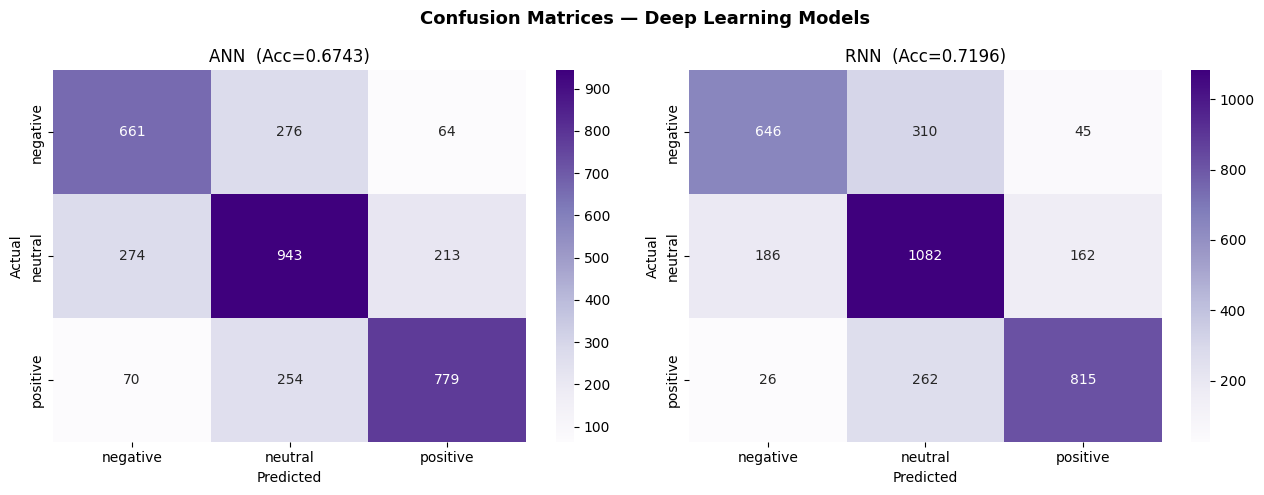

In [35]:
# ── DL Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, preds in zip(axes,
                            ['ANN', 'RNN'],
                            [ann_preds, rnn_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap='Purples')
    ax.set_title(f"{name}  (Acc={accuracy_score(y_test, preds):.4f})", fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Deep Learning Models', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


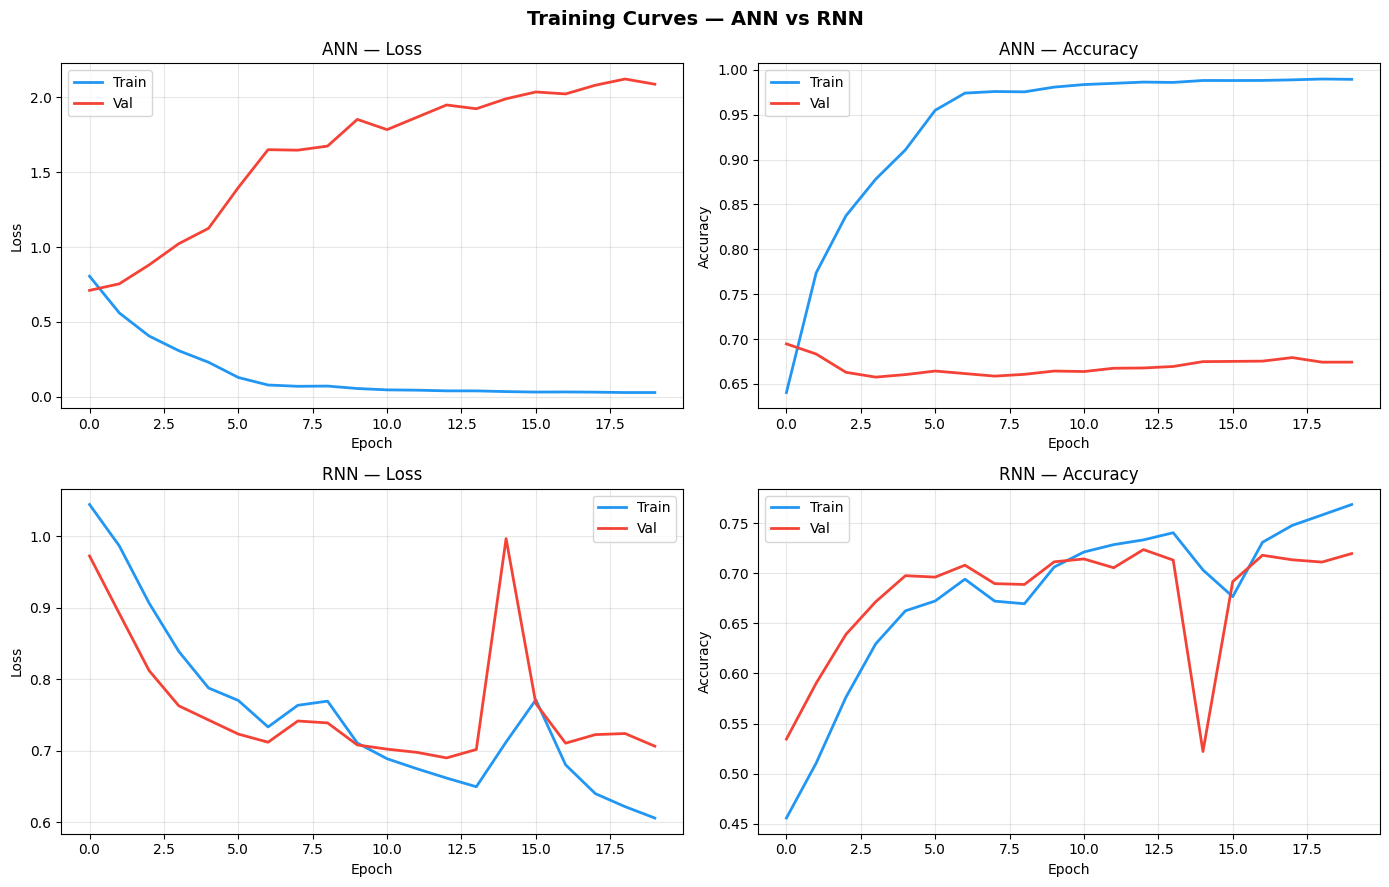

In [36]:
# ── Training Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (name, hist) in enumerate(zip(['ANN', 'RNN'],
                                        [ann_history, rnn_history])):
    axes[row, 0].plot(hist['train_loss'], label='Train', color='#2196F3', lw=2)
    axes[row, 0].plot(hist['test_loss'],  label='Val',   color='#F44336', lw=2)
    axes[row, 0].set_title(f'{name} — Loss', fontsize=12)
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(hist['train_acc'], label='Train', color='#2196F3', lw=2)
    axes[row, 1].plot(hist['test_acc'],  label='Val',   color='#F44336', lw=2)
    axes[row, 1].set_title(f'{name} — Accuracy', fontsize=12)
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.suptitle('Training Curves — ANN vs RNN', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## **7️⃣ Final Comparison — ML Models vs ANN vs RNN**

Comparing all models on:
- **Accuracy**
- **Training Time (s)**
- **Inference / Evaluation Time (s)**


In [31]:
# ── Measure inference times for DL models ───────────────────────────────────
import time

def dl_inference_time(model, loader):
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            _ = model(xb)
    return time.time() - t0

ann_infer = dl_inference_time(ann_model, ann_test_loader)
rnn_infer = dl_inference_time(rnn_model, rnn_test_loader)

In [37]:
# ── Build comparison DataFrame ───────────────────────────────────────────────
rows = []
for name, res in ml_results.items():
    rows.append({
        'Model':          name,
        'Type':           'ML',
        'Accuracy':       round(res['accuracy'], 4),
        'Train Time (s)': round(res['train_time'], 3),
        'Infer Time (s)': round(res['infer_time'], 4),
    })

rows.append({
    'Model':          'ANN',
    'Type':           'Deep Learning',
    'Accuracy':       round(ann_acc, 4),
    'Train Time (s)': round(ann_train_time, 2),
    'Infer Time (s)': round(ann_infer, 4),
})
rows.append({
    'Model':          'RNN ',
    'Type':           'Deep Learning',
    'Accuracy':       round(rnn_acc, 4),
    'Train Time (s)': round(rnn_train_time, 2),
    'Infer Time (s)': round(rnn_infer, 4),
})

comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df.style.background_gradient(cmap='Greens', subset=['Accuracy']) \
                   .background_gradient(cmap='Reds_r',  subset=['Train Time (s)']) \
                   .format({'Accuracy': '{:.4f}', 'Train Time (s)': '{:.3f}',
                            'Infer Time (s)': '{:.4f}'})


,Type,Accuracy,Train Time (s),Infer Time (s)
Model,,,,
Logistic Regression,ML,0.7043,2.118,0.0010
Naive Bayes,ML,0.6290,0.007,0.0009
SVM (Linear),ML,0.6703,0.536,0.0008
Random Forest,ML,0.7074,159.280,1.5222
ANN,Deep Learning,0.6743,49.400,0.1057
RNN,Deep Learning,0.7196,43.580,0.0838


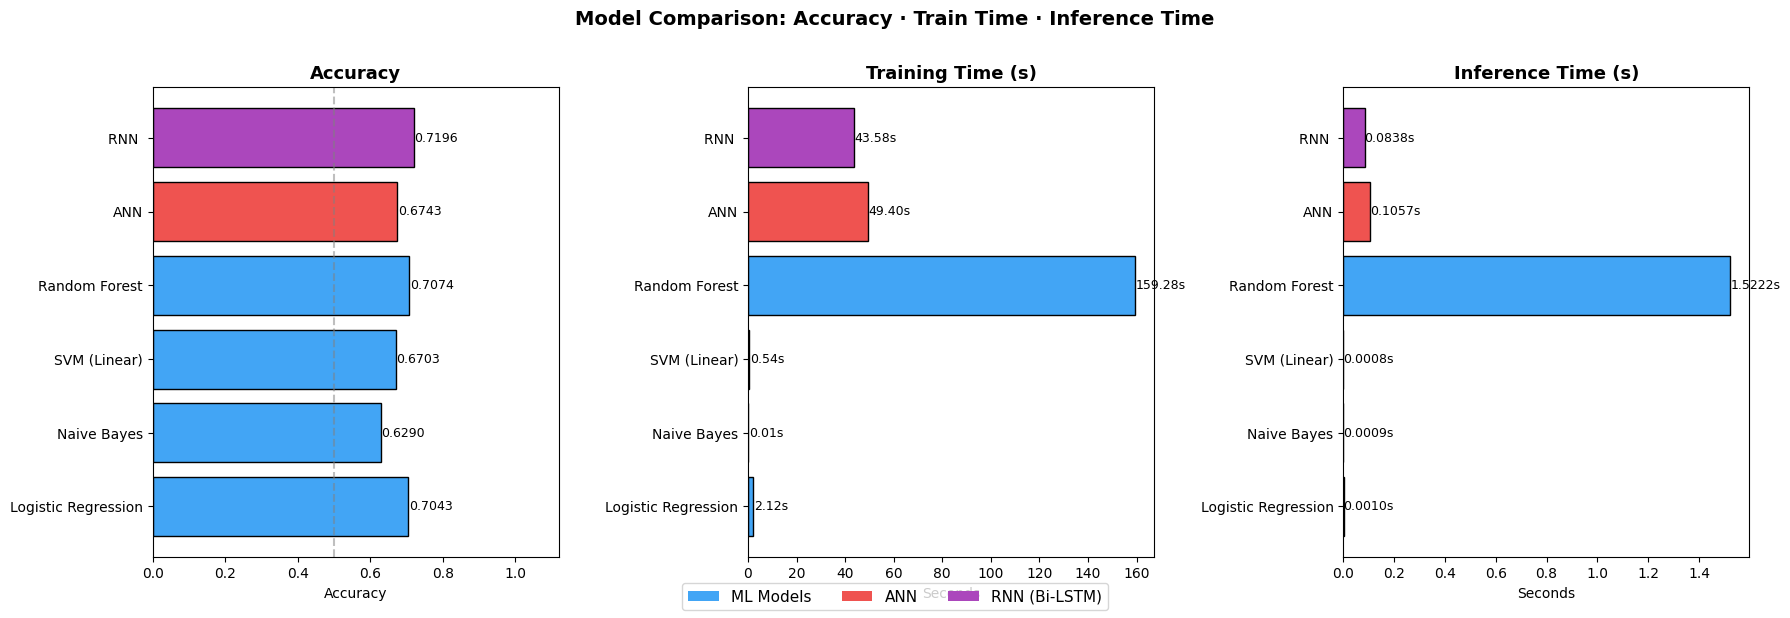

In [38]:
# ── Accuracy comparison bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models_list  = comparison_df.index.tolist()
colors = ['#42A5F5','#42A5F5','#42A5F5','#42A5F5',   # ML models
          '#EF5350','#AB47BC']                          # DL models

# Accuracy
bars = axes[0].barh(models_list, comparison_df['Accuracy'], color=colors, edgecolor='black')
for bar, v in zip(bars, comparison_df['Accuracy']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
axes[0].set_xlim(0, 1.12)
axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

# Training time
bars2 = axes[1].barh(models_list, comparison_df['Train Time (s)'], color=colors, edgecolor='black')
for bar, v in zip(bars2, comparison_df['Train Time (s)']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}s', va='center', fontsize=9)
axes[1].set_title('Training Time (s)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Seconds')

# Inference time
bars3 = axes[2].barh(models_list, comparison_df['Infer Time (s)'], color=colors, edgecolor='black')
for bar, v in zip(bars3, comparison_df['Infer Time (s)']):
    axes[2].text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}s', va='center', fontsize=9)
axes[2].set_title('Inference Time (s)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Seconds')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#42A5F5', label='ML Models'),
                   Patch(facecolor='#EF5350', label='ANN'),
                   Patch(facecolor='#AB47BC', label='RNN (Bi-LSTM)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11, frameon=True)
plt.suptitle('Model Comparison: Accuracy · Train Time · Inference Time',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **📝 Summary & Conclusions**

| Model | Strength | Limitation |
|---|---|---|
| **Logistic Regression** | Fast, interpretable, strong baseline | Linear boundary only |
| **Naive Bayes** | Very fast training, works on small data | Strong independence assumption |
| **SVM (Linear)** | Often best ML accuracy on text | Slow inference for large datasets |
| **Random Forest** | Robust to noise | Slow to train, large memory |
| **ANN (PyTorch)** | Captures non-linear patterns, GPU-ready | Needs tuning, no word order |
| **RNN ** | Understands word order & context | Slowest to train |

**Key takeaways:**
- Classical ML models (especially SVM & LR) are competitive for text classification due to the effectiveness of TF-IDF.
- The **RNN** captures sequential context and typically edges ahead on nuanced sentiment.
- **ANN** sits in the middle: faster than RNN, more expressive than linear models.
- For production with limited compute, **Logistic Regression** or **SVM** are strong choices.
- For best accuracy with sufficient data, the **RNN** or a transformer-based model is preferred.
